# **CMSC320 Project Final Tutorial** 

**Title:** Funky Title Name Here

**Subject:** Spring 2026 CMSC320 Project

**Team Members:** Max Dustin, Seth Calhoon, Spencer Feldmann, Aaryashree Sapkota, Laura Nino Gutierrez

**Contributions:**
- Max D: Project Idea, Data Curation & Preprocessing, Final Tutorial Report Creation
- Seth C: Data Exploration & Summary Statistics
- Spencer F: Data Exploration & Summary Statistics, Introduction Section
- Aaryashree S: Data Exploration & Summary Statistics
- Laura G:

**Table of Contents:**
1) [Introduction](#section-1---introduction)
2) [Data Curation](#section-2---data-curation)
3) [Exploratory Data Analysis](#section-3---exploratory-data-analysis)
4) [Primary Analysis](#section-4---primary-analysis)
5) [Visualization](#section-5---visualization)
6) [Insights & Conclusions](#section-6---insights--conclusions)
    


## **Section 1 - Introduction**

Weather shapes nearly every system humans depend on. Agriculture, energy, transportation, and disaster response all depend on atmospheric conditions that vary enormously by location and season. Yet the data behind those conditions is often scattered, hard to interpret, and rarely examined across different regions of the world in a unified way.
This tutorial walks through a full data science analysis using a subset of the ERA5 dataset, a global weather product produced by the European Centre for Medium-Range Weather Forecasts (ECMWF) and accessed through the Copernicus Climate Data Store. The dataset covers monthly weather observations recorded across 30 cities on all 7 continents, spanning 2021 to 2025. Measurements include near-surface air temperature, dewpoint temperature, surface pressure, wind speed, snowfall, snow depth, evaporation, runoff, and soil type.
With global warming and climate change being discussed more than ever, we wanted to look at five years of global weather data to see if any significant patterns or effects stand out across different regions of the world. Understanding those patterns may also help with making better predictions about future weather conditions.
Three questions drive the analysis. First, how do weather conditions differ across continents and latitude bands? Second, which variables are most strongly related to near-surface air temperature? Third, can we use location and weather data to accurately predict temperature? To answer that last question, we build and compare two models, a Linear Regression model and a Random Forest Regression model, to see which one better captures the patterns in the data.
The goal of this tutorial is to show how a well-structured dataset and a step-by-step analysis can turn raw weather records into something genuinely useful and easy to understand.


## **Section 2 - Data Curation**

We will be using a subset of the "ERA5 monthly averaged data on single levels from 1940 to present" dataset. ERA5 is a global weather dataset containing hourly atmospheric, ground, and oceanic weather data since 1940. This specific dataset contains those values averaged over each month.

Below will include full steps on how to go about retrieving and simplifying this dataset, however it is highly recommended you download the converted dataset from this repository to avoid having to go through the whole process by going [here](#download-subset-from-repository-method-2)

### **Full Dataset Retrieval and Conversion (Method 1)**

The dataset can be found on the Climate Data Store here (you will need to make a free account first): https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means?tab=overview

This dataset is massive and we do not need to download or use all of it. Instead we will select a smaller subset using the API. To properly use the API, please follow these setup instructions: https://cds.climate.copernicus.eu/how-to-api

Uncomment and run the code block below to make a request to CDS

In [53]:
# import cdsapi
# 
# dataset = "reanalysis-era5-single-levels-monthly-means"
# request = {
# "product_type": ["monthly_averaged_reanalysis_by_hour_of_day"],
# "variable": [
#     "10m_u_component_of_wind",
#     "10m_v_component_of_wind",
#     "2m_dewpoint_temperature",
#     "2m_temperature",
#     "surface_pressure",
#     "total_precipitation",
#     "evaporation",
#     "runoff",
#     "soil_temperature_level_1",
#     "soil_type",
#     "snowfall",
#     "snow_depth"
# ],
# "year": [
#     "2021", "2022", "2023",
#     "2024", "2025"
# ],
# "month": [
#     "01", "02", "03",
#     "04", "05", "06",
#     "07", "08", "09",
#     "10", "11", "12"
# ],
# "time": ["12:00"],
# "data_format": "grib",
# "download_format": "unarchived"
# }
# 
# client = cdsapi.Client()
# client.retrieve(dataset, request).download()

Now that the request has been made, go back to the Climate Data Store website and click on "Your requests" in the top right corner below your username. Wait for the request to complete.

Once the request has completed, download the dataset (this will take a while).

Now that we have the dataset downloaded we will need to store it in a SQL database so that we can query it and select a better defined subset. Weather datasets are typically stored as GRIB (GRIdded binary) files, so we will need to handle it by converting it to a dataframe and them storing it using sqlite3 (SQL database), xarray (handling large multidimensional arrays), and cfgrib (works with xarray to handle GRIB data). Uncomment and run the code block below to convert and store the dataset.

**Note:** It is at this point where having a lot of computer memory is necessary. If this is not the case for you, this process may crash your computer. This is why it is recommended that you simply download the dataset from the repository by following the steps [here](#download-subset-from-repository-method-2).

In [54]:
# import pandas as pd
# import sqlite3
# import xarray as xr
# import cfgrib

# # open and combine GRIB dataset    
# datasets = cfgrib.open_datasets('era5_subset.grib')
# ds = xr.merge(datasets, compat='override', combine_attrs='drop')

# # converting to DataFrame object risks memory overload due to limited RAM capacity for some computers
# df = ds.to_dataframe().reset_index()


# database_file = 'era5_database.sqlite'
# main_table = 'main'

# # connect to and create SQL database
# conn = sqlite3.connect(database_file)

# df.to_sql(main_table, conn, if_exists='replace', index=False, chunksize=10000)

# conn.close()

Now that we have the data in a database, we will want to get the weather data for specific locations. We curated a list of 30 locations on Earth from all 7 continents. This list can be found in the repository, however you can also create an empty CSV file titled "cities.csv" and paste the following text contained inside the triple quotes into it

In [55]:
"""
location,continent,latitude,longitude
"Tokyo, Japan",Asia,35.75,139.75
"Singapore, Singapore",Asia,1.25,103.75
"Dubai, UAE",Asia,25.25,55.25
"Beijing, China",Asia,40.0,116.5
"Mumbai, India",Asia,19.0,73.0
"Seoul, South Korea",Asia,37.5,127.0
"Bangkok, Thailand",Asia,13.75,100.5
"New York City, NY",North America,40.75,286.0
"Los Angeles, CA",North America,34.0,241.75
"Chicago, IL",North America,42.0,272.25
"Mexico City, Mexico",North America,19.5,260.75
"Miami, FL",North America,25.75,279.75
"Vancouver, Canada",North America,49.25,237.0
"Sao Paulo, Brazil",South America,-23.5,313.25
"Buenos Aires, Argentina",South America,-34.5,301.5
"Lima, Peru",South America,-12.0,283.0
"Rio de Janeiro, Brazil",South America,-23.0,316.75
"Bogota, Colombia",South America,4.75,286.0
"Cairo, Egypt",Africa,30.0,31.25
"Lagos, Nigeria",Africa,6.5,3.5
"Nairobi, Kenya",Africa,-1.25,36.75
"Cape Town, South Africa",Africa,-34.0,18.5
"London, United Kingdom",Europe,51.5,0.0
"Paris, France",Europe,48.75,2.25
"Moscow, Russia",Europe,55.75,37.5
"Sydney, Australia",Oceania,-33.75,151.25
"Melbourne, Australia",Oceania,-37.75,145.0
"Perth, Australia",Oceania,-32.0,115.75
"McMurdo Station, Antarctica",Antarctica,-77.75,166.75
"Amundsen-Scott, Antarctica",Antarctica,-90.0,0.0
"""

'\nlocation,continent,latitude,longitude\n"Tokyo, Japan",Asia,35.75,139.75\n"Singapore, Singapore",Asia,1.25,103.75\n"Dubai, UAE",Asia,25.25,55.25\n"Beijing, China",Asia,40.0,116.5\n"Mumbai, India",Asia,19.0,73.0\n"Seoul, South Korea",Asia,37.5,127.0\n"Bangkok, Thailand",Asia,13.75,100.5\n"New York City, NY",North America,40.75,286.0\n"Los Angeles, CA",North America,34.0,241.75\n"Chicago, IL",North America,42.0,272.25\n"Mexico City, Mexico",North America,19.5,260.75\n"Miami, FL",North America,25.75,279.75\n"Vancouver, Canada",North America,49.25,237.0\n"Sao Paulo, Brazil",South America,-23.5,313.25\n"Buenos Aires, Argentina",South America,-34.5,301.5\n"Lima, Peru",South America,-12.0,283.0\n"Rio de Janeiro, Brazil",South America,-23.0,316.75\n"Bogota, Colombia",South America,4.75,286.0\n"Cairo, Egypt",Africa,30.0,31.25\n"Lagos, Nigeria",Africa,6.5,3.5\n"Nairobi, Kenya",Africa,-1.25,36.75\n"Cape Town, South Africa",Africa,-34.0,18.5\n"London, United Kingdom",Europe,51.5,0.0\n"Paris, Fra

We can now query the database for all the data regarding each of the individual locations we have stored in our cities file. We will store this data in a file titled "weather.csv" (can also be found in the repository). Uncomment and run the following code block to create our CSV.

In [56]:
# database_file = 'era5_database.sqlite'
# main_table = 'main'

# # reconnect to SQL database
# conn = sqlite3.connect(database_file)

# # select subset from dataset based on selected cities/locations
# city_df = pd.read_csv("cities.csv")
# s_df = pd.read_sql("SELECT * FROM main LIMIT 0", conn) # get column format

# # for each city get the associated datapoints
# for _, row in city_df.iterrows(): # get all weather data for each location
#     query = f"""SELECT * FROM main WHERE latitude = {row['latitude']} AND longitude = {row['longitude']}"""
#     s_df = pd.concat([s_df, pd.read_sql(query, conn)], ignore_index=True)

# # save subset as CSV file
# s_df.to_csv("weather.csv", index=False)
# conn.close()

### **Download Subset from Repository (Method 2)**

There are two datasets you will need to download before continuing.

1) *weather.csv* - This file contains the desired subset of data from the original ERA5 dataset described at the beginning of this section. This is the main dataset we will be using throughout the entire tutorial.
2) *cities.csv* - This file contains a list of 30 cities around the world with their corresponding latitude, longitude, name, and continent. This will be used to group the dataset above by location.

Go ahead and download these two from the repository (if you have not done so already) and add them to the same directory as this project.

### **Data Cleaning**

Now that we have our dataset set up, we can now begin cleaning. This a critical step before we begin exploratory analysis, otherwise the data becomes increasingly difficult to work with.

**Step 1.1:** Import necessary libraries

In [57]:
import pandas as pd ## Data handeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

**Step 1.2:** Import dataset from CSV file

In [58]:
weather_df = pd.read_csv("weather.csv")

weather_df.head()

,time,latitude,longitude,number,step,depthBelowLandLayer,valid_time,stl1,surface,slt,sp,sd,u10,v10,t2m,d2m,sf,e,ro,tp
0,2021-01-01 06:00:00,35.75,139.75,0,0 days,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,-0.000041,0.000015,0.000065
1,2021-01-01 12:00:00,35.75,139.75,0,0 days,0.0,2021-01-01 12:00:00,279.91925,0.0,3.0,101900.016,0.000084,0.187966,-2.449815,277.37920,272.67170,NaN,NaN,NaN,NaN
2,2021-02-01 06:00:00,35.75,139.75,0,0 days,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.980232e-08,-0.000041,0.000011,0.000005
3,2021-02-01 12:00:00,35.75,139.75,0,0 days,0.0,2021-02-01 12:00:00,281.76420,0.0,3.0,101633.664,0.000000,0.555573,-0.719503,280.37323,273.26367,NaN,NaN,NaN,NaN
4,2021-03-01 06:00:00,35.75,139.75,0,0 days,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,-0.000030,0.000009,0.000077


In [59]:
import os

print("Python is currently looking in:", os.getcwd())
print("Files in this folder:", os.listdir())

Python is currently looking in: c:\Users\semic\OneDrive\Documents\CMSC320\Final Project\CMSC320_SemesterProject
Files in this folder: ['.git', 'Checkpoint_Submissions', 'cities.csv', 'data_cleaning.ipynb', 'data_exploration.ipynb', 'final_tutorial.ipynb', 'grib_to_csv.py', 'README.md', 'sql_database_setup.py', 'subset_selection.ipynb', 'weather.csv']


**Step 1.3:** Keep important columns, discard the rest.

In [60]:
weather_df = weather_df[['time', 'latitude', 'longitude', 'stl1', 'slt', 'sp', 'sd', 'u10', 'v10', 't2m', 'd2m', 'sf', 'e', 'ro', 'tp']]

**Step 1.4:** Display data types of **weather_df** columns.

In [61]:
weather_df.dtypes

time             str
latitude     float64
longitude    float64
stl1         float64
slt          float64
sp           float64
sd           float64
u10          float64
v10          float64
t2m          float64
d2m          float64
sf           float64
e            float64
ro           float64
tp           float64
dtype: object

**Step 1.5:** Note that the 'time' column is stored as a string. We will convert it to a datetime object and only store the day, month, and year for convenience.

In [62]:
weather_df['time'] = weather_df['time'].apply(
    lambda x : pd.to_datetime(x[0:10], format='%Y-%m-%d')
)

weather_df.head()

,time,latitude,longitude,stl1,slt,sp,sd,u10,v10,t2m,d2m,sf,e,ro,tp
0,2021-01-01,35.75,139.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,-0.000041,0.000015,0.000065
1,2021-01-01,35.75,139.75,279.91925,3.0,101900.016,0.000084,0.187966,-2.449815,277.37920,272.67170,NaN,NaN,NaN,NaN
2,2021-02-01,35.75,139.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.980232e-08,-0.000041,0.000011,0.000005
3,2021-02-01,35.75,139.75,281.76420,3.0,101633.664,0.000000,0.555573,-0.719503,280.37323,273.26367,NaN,NaN,NaN,NaN
4,2021-03-01,35.75,139.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,-0.000030,0.000009,0.000077


**Step 1.6:** Due to the way the data was recorded, each location and time has two entires. One for ground data, and the other for air (more specifically: percipitation related data). For each entry, we will combine it with its pair to remove missing data.

In [63]:
weather_df = weather_df.groupby(['time', 'latitude', 'longitude']).max().reset_index()

weather_df.head()

,time,latitude,longitude,stl1,slt,sp,sd,u10,v10,t2m,d2m,sf,e,ro,tp
0,2021-01-01,-90.00,0.00,232.94269,1.0,68938.016,10.000000,0.380349,0.006728,244.23468,240.34161,0.000002,3.189780e-07,0.000000e+00,0.000002
1,2021-01-01,-77.75,166.75,267.34894,0.0,96918.016,4.021423,-1.187522,-0.171983,268.30695,263.42755,0.000030,-1.464179e-05,0.000000e+00,0.000030
2,2021-01-01,-37.75,145.00,292.26690,4.0,100400.016,0.000000,0.876931,2.148818,290.45734,286.12677,0.000000,-3.708294e-05,1.072884e-06,0.000082
3,2021-01-01,-34.50,301.50,298.18097,0.0,101219.016,0.000000,-0.640159,-0.776475,296.24054,289.96466,0.000000,-2.151071e-04,1.192093e-07,0.000067
4,2021-01-01,-34.00,18.50,295.90167,1.0,100912.016,0.000000,0.170388,5.962783,294.80304,288.18146,0.000000,-6.900122e-05,0.000000e+00,0.000003


**Step 1.7:** Rename columns for clarity.

In [64]:
weather_df.columns = ['date', 'latitude', 'longitude', 'soil_temperature_level_1', 'soil_type', 'surface_pressure', 'snow_depth', 
    'u_wind_10m', 'v_wind_10m', 'temperature_2m', 'dewpoint_temperature_2m', 'snowfall', 'evaporation', 'runoff', 'total_percipitation']

weather_df.head()

,date,latitude,longitude,soil_temperature_level_1,soil_type,surface_pressure,snow_depth,u_wind_10m,v_wind_10m,temperature_2m,dewpoint_temperature_2m,snowfall,evaporation,runoff,total_percipitation
0,2021-01-01,-90.00,0.00,232.94269,1.0,68938.016,10.000000,0.380349,0.006728,244.23468,240.34161,0.000002,3.189780e-07,0.000000e+00,0.000002
1,2021-01-01,-77.75,166.75,267.34894,0.0,96918.016,4.021423,-1.187522,-0.171983,268.30695,263.42755,0.000030,-1.464179e-05,0.000000e+00,0.000030
2,2021-01-01,-37.75,145.00,292.26690,4.0,100400.016,0.000000,0.876931,2.148818,290.45734,286.12677,0.000000,-3.708294e-05,1.072884e-06,0.000082
3,2021-01-01,-34.50,301.50,298.18097,0.0,101219.016,0.000000,-0.640159,-0.776475,296.24054,289.96466,0.000000,-2.151071e-04,1.192093e-07,0.000067
4,2021-01-01,-34.00,18.50,295.90167,1.0,100912.016,0.000000,0.170388,5.962783,294.80304,288.18146,0.000000,-6.900122e-05,0.000000e+00,0.000003


**Step 1.8:** In order to add location name data to the dataset, we will use *cities.csv* which maps latitude and longitude to a city/location. First we need to import it into a dataframe.

In [65]:
city_df = pd.read_csv('cities.csv')

city_df

,location,continent,latitude,longitude
0,"Tokyo, Japan",Asia,35.75,139.75
1,"Singapore, Singapore",Asia,1.25,103.75
2,"Dubai, UAE",Asia,25.25,55.25
3,"Beijing, China",Asia,40.00,116.50
4,"Mumbai, India",Asia,19.00,73.00
5,"Seoul, South Korea",Asia,37.50,127.00
6,"Bangkok, Thailand",Asia,13.75,100.50
7,"New York City, NY",North America,40.75,286.00
8,"Los Angeles, CA",North America,34.00,241.75
9,"Chicago, IL",North America,42.00,272.25


**Step 1.9:** Use **pandas** merge() function to combine the two dataframes on latitude and longitude.

In [66]:
full_df = weather_df.merge(city_df, how='left', on=['longitude', 'latitude'])

full_df.head()

,date,latitude,longitude,soil_temperature_level_1,soil_type,surface_pressure,snow_depth,u_wind_10m,v_wind_10m,temperature_2m,dewpoint_temperature_2m,snowfall,evaporation,runoff,total_percipitation,location,continent
0,2021-01-01,-90.00,0.00,232.94269,1.0,68938.016,10.000000,0.380349,0.006728,244.23468,240.34161,0.000002,3.189780e-07,0.000000e+00,0.000002,"Amundsen-Scott, Antarctica",Antarctica
1,2021-01-01,-77.75,166.75,267.34894,0.0,96918.016,4.021423,-1.187522,-0.171983,268.30695,263.42755,0.000030,-1.464179e-05,0.000000e+00,0.000030,"McMurdo Station, Antarctica",Antarctica
2,2021-01-01,-37.75,145.00,292.26690,4.0,100400.016,0.000000,0.876931,2.148818,290.45734,286.12677,0.000000,-3.708294e-05,1.072884e-06,0.000082,"Melbourne, Australia",Oceania
3,2021-01-01,-34.50,301.50,298.18097,0.0,101219.016,0.000000,-0.640159,-0.776475,296.24054,289.96466,0.000000,-2.151071e-04,1.192093e-07,0.000067,"Buenos Aires, Argentina",South America
4,2021-01-01,-34.00,18.50,295.90167,1.0,100912.016,0.000000,0.170388,5.962783,294.80304,288.18146,0.000000,-6.900122e-05,0.000000e+00,0.000003,"Cape Town, South Africa",Africa


**Step 1.10:** From looking at the dtypes earlier, we note that soil_type is stored as a float64 despite containing int (whole number) data. soil_type is categorical data stored through ordinal encoding. While we are at it, we will reorder the column order to make things more ordered and grouped together visually.

In [67]:
full_df['soil_type'] = full_df['soil_type'].astype('int64')

full_df = full_df[['location', 'continent', 'date', 'latitude', 'longitude', 'temperature_2m', 'surface_pressure', 'dewpoint_temperature_2m'
    , 'v_wind_10m', 'u_wind_10m', 'evaporation', 'runoff', 'total_percipitation', 'snowfall', 'snow_depth', 'soil_temperature_level_1', 'soil_type']]

full_df.head()

,location,continent,date,latitude,longitude,temperature_2m,surface_pressure,dewpoint_temperature_2m,v_wind_10m,u_wind_10m,evaporation,runoff,total_percipitation,snowfall,snow_depth,soil_temperature_level_1,soil_type
0,"Amundsen-Scott, Antarctica",Antarctica,2021-01-01,-90.00,0.00,244.23468,68938.016,240.34161,0.006728,0.380349,3.189780e-07,0.000000e+00,0.000002,0.000002,10.000000,232.94269,1
1,"McMurdo Station, Antarctica",Antarctica,2021-01-01,-77.75,166.75,268.30695,96918.016,263.42755,-0.171983,-1.187522,-1.464179e-05,0.000000e+00,0.000030,0.000030,4.021423,267.34894,0
2,"Melbourne, Australia",Oceania,2021-01-01,-37.75,145.00,290.45734,100400.016,286.12677,2.148818,0.876931,-3.708294e-05,1.072884e-06,0.000082,0.000000,0.000000,292.26690,4
3,"Buenos Aires, Argentina",South America,2021-01-01,-34.50,301.50,296.24054,101219.016,289.96466,-0.776475,-0.640159,-2.151071e-04,1.192093e-07,0.000067,0.000000,0.000000,298.18097,0
4,"Cape Town, South Africa",Africa,2021-01-01,-34.00,18.50,294.80304,100912.016,288.18146,5.962783,0.170388,-6.900122e-05,0.000000e+00,0.000003,0.000000,0.000000,295.90167,1


**Step 1.11:** Before saving this dataframe into a file, we will first check that everything looks alright.

In [68]:
full_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   location                  1800 non-null   str           
 1   continent                 1800 non-null   str           
 2   date                      1800 non-null   datetime64[us]
 3   latitude                  1800 non-null   float64       
 4   longitude                 1800 non-null   float64       
 5   temperature_2m            1800 non-null   float64       
 6   surface_pressure          1800 non-null   float64       
 7   dewpoint_temperature_2m   1800 non-null   float64       
 8   v_wind_10m                1800 non-null   float64       
 9   u_wind_10m                1800 non-null   float64       
 10  evaporation               1800 non-null   float64       
 11  runoff                    1800 non-null   float64       
 12  total_percipitation       1800 

We notice that there are no null values, and that every column is stored as the desired dtype. Now it is time to perform data exploration on the cleaned dataset.

## **Section 3 - Exploratory Data Analysis**

**Step 2.1:** Import additional necessary libraries

In [69]:
from scipy.stats import f_oneway ## For ANOVA test
from scipy.stats import tukey_hsd ## Post-hoc test for ANOVA

import matplotlib.pyplot as plt ## Plotting
import seaborn as sns ## Plotting

**Step 2.2:** Perform first data exploration.

Intro:
One way that we are going to explore the dataset is by looking at how the different variables correlate to each other. Measuring the relationship between the variables can show us which variables are linked. The correlation number ranges from -1 (perfect negative correlation) to +1 (perfect positive correlation).

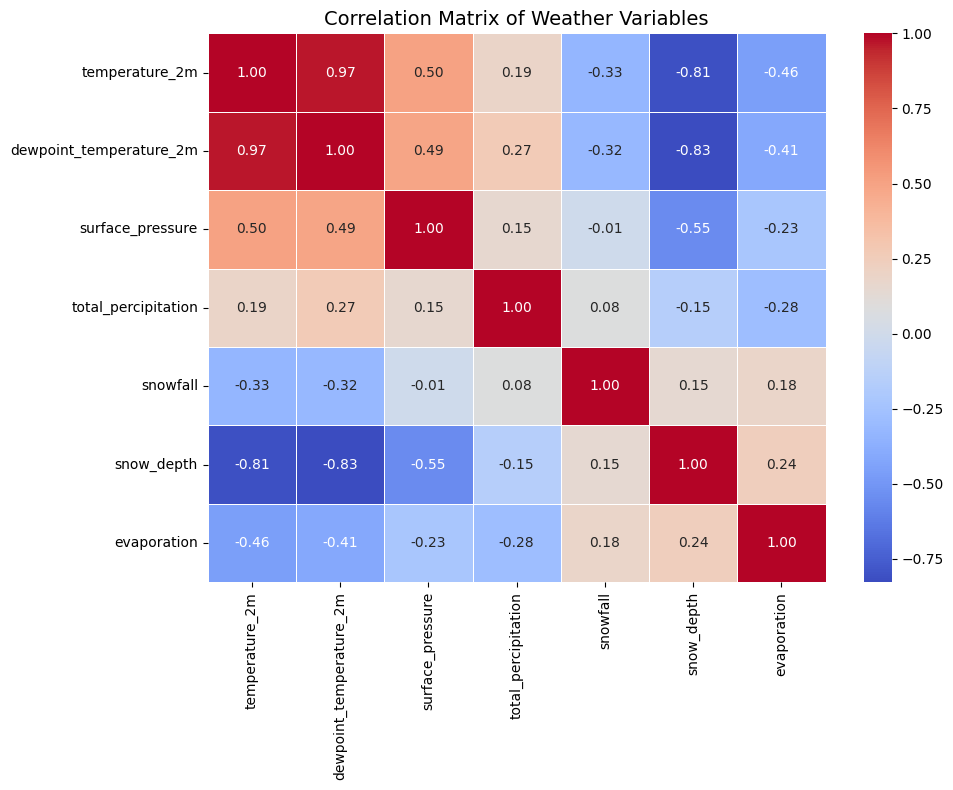

In [70]:
df = full_df

corr_cols = [
    "temperature_2m",
    "dewpoint_temperature_2m",
    "surface_pressure",
    "total_percipitation",
    "snowfall",
    "snow_depth",
    "evaporation"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Weather Variables", fontsize=14)
plt.tight_layout()
plt.show()

Conclusion:
It is clear that temperature and dewpoint are strongly correlated, .97, which makes sense since warm air holds more moisture, so they rise and fall together. Snow depth and temperature is strongly negatively correlated, -.81, pretty obvious that cold air leads to more snow. Snow depth and dewpoint are also strongly negative, -.83, because drier cold air means more snow sticks. Surface pressure and temperature are moderately positive, .5, since warmer air can create higher pressure systems. And precipitation is weakly correlated with pretty much everything, which is because rain depends on more complex factors, not just temperature.

**Step 2.3:** Perform second data exploration.

Intro: We can perform quantile analysis to determine how the spread of global temperature statistics is being affected by each continent.

--- Five-Number Summary for Temperature (K) ---
0.00    213.459440
0.25    283.468825
0.50    291.365230
0.75    298.432658
1.00    311.771500
Name: temperature_2m, dtype: float64

Global Mean: 288.29K
Global Median (50%): 291.37K
Skewness indicator (Mean - Median): -3.08

--- Grouped Temperature Statistics by Continent ---
                     mean         50%        std        min        max
continent                                                             
Africa         298.454338  298.651885   5.446771  287.24640  310.70563
Antarctica     241.780144  245.692750  16.364284  213.45944  269.04803
Asia           296.223089  300.549820  10.239304  269.03314  311.77150
Europe         286.253548  286.249695   8.321810  263.63990  300.32767
North America  285.538428  284.784350   8.040009  265.26776  301.52570
Oceania        289.908465  289.777985   4.371169  280.73035  299.07600
South America  291.196757  291.659500   5.516678  280.07648  302.48280


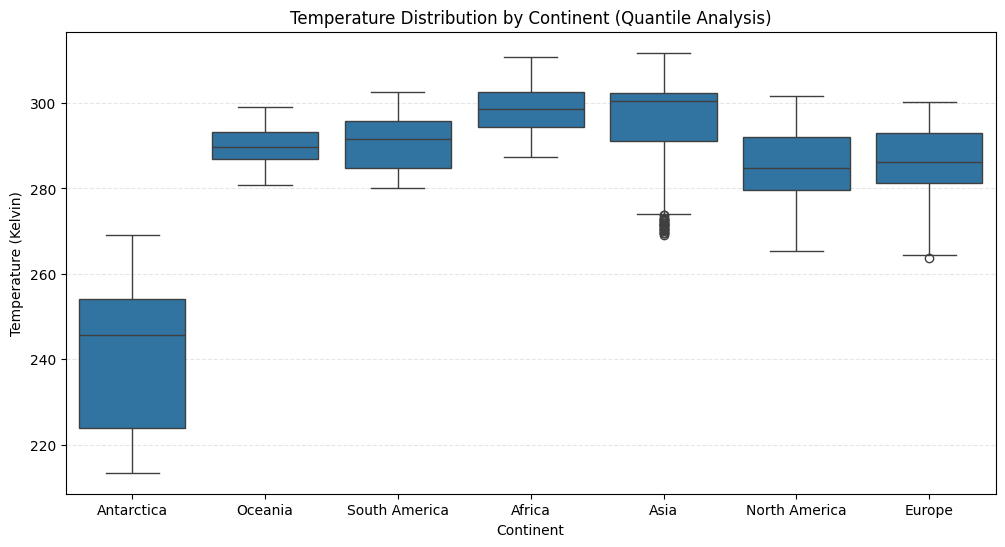

In [71]:
df = full_df
temp_quantiles = df['temperature_2m'].quantile([0.0, 0.25, 0.5, 0.75, 1.0])
print("--- Five-Number Summary for Temperature (K) ---")
print(temp_quantiles)

mean = df['temperature_2m'].mean()
median = df['temperature_2m'].median()
print(f"\nGlobal Mean: {mean:.2f}K")
print(f"Global Median (50%): {median:.2f}K")
print(f"Skewness indicator (Mean - Median): {mean - median:.2f}")

grouped_stats = df.groupby('continent')['temperature_2m'].describe()
print("\n--- Grouped Temperature Statistics by Continent ---")
print(grouped_stats[['mean', '50%', 'std', 'min', 'max']])

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='continent', y='temperature_2m')
plt.title('Temperature Distribution by Continent (Quantile Analysis)')
plt.ylabel('Temperature (Kelvin)')
plt.xlabel('Continent')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Conclusion: The global temperature distribution is negatively skewed, as the mean is lower than the median. The box plot shows that this is due to how extreme the lows are in Antarctica compared to the rest of the world. Antarctica has a low of 213.46, which is roughly 50 degrees less than the low of the next closest continent, Europe.

**Step 2.4:** Perform third data exploration.

Intro: We perform a hypothesis test to determine whether the latitude band in which the cities reside have an effect on the total percipitation. We will do this by first running an ANOVA test then following it with a HSD post-hoc test to either support or reject the null hypothsis that total precipitation across latitude bands is the same.

In [72]:
#Null Hypothesis: Total precipitation across latitude bands is the same.
#Alternative Hypothesis: Total precipitation across latitude bands is not the same.

hypo_df = full_df

hypo_df['latitude_bands'] = pd.cut(hypo_df['latitude'], bins=[-90, -30, 30, 90], labels=['Southern', 'Mid', 'Northern'], include_lowest=True)

hypo_df['total_precipitation_mm'] = hypo_df['total_percipitation'] * 1000
rainy_days_df = hypo_df[hypo_df['total_precipitation_mm'] > 0]
# rainy_days_df.groupby('latitude_bands')['total_precipitation_mm'].describe()

south = rainy_days_df[rainy_days_df['latitude_bands'] == 'Southern']['total_precipitation_mm']
mid = rainy_days_df[rainy_days_df['latitude_bands'] == 'Mid']['total_precipitation_mm']
north = rainy_days_df[rainy_days_df['latitude_bands'] == 'Northern']['total_precipitation_mm']


f_statistic, p_value = f_oneway(south, mid, north)

print(f"P-value: {p_value}")

P-value: 7.14255303567513e-11


In [73]:
result = tukey_hsd(south, mid, north)
print(result)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.062     0.000    -0.083    -0.040
 (0 - 2)     -0.044     0.000    -0.066    -0.022
 (1 - 0)      0.062     0.000     0.040     0.083
 (1 - 2)      0.018     0.076    -0.001     0.037
 (2 - 0)      0.044     0.000     0.022     0.066
 (2 - 1)     -0.018     0.076    -0.037     0.001



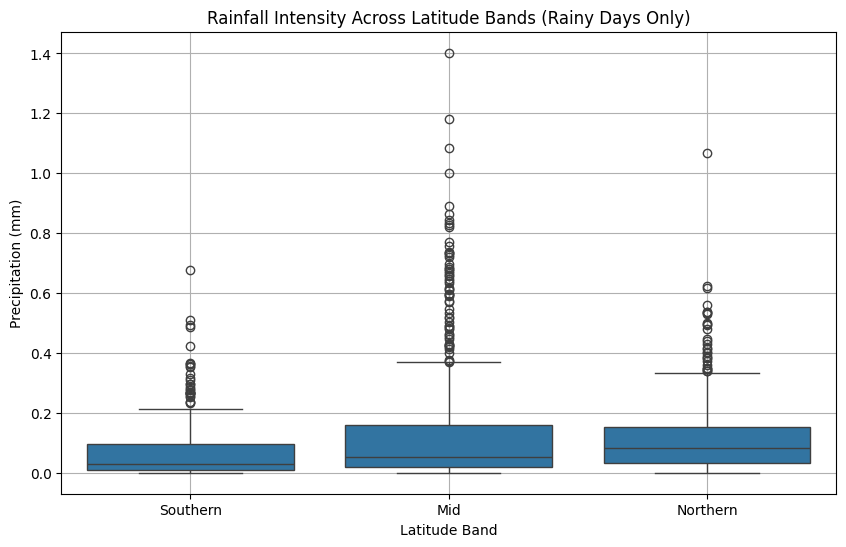

In [74]:
plt.figure(figsize=(10,6))
sns.boxplot(data=rainy_days_df, x='latitude_bands', y='total_precipitation_mm')

plt.title('Rainfall Intensity Across Latitude Bands (Rainy Days Only)')
plt.xlabel('Latitude Band')
plt.ylabel('Precipitation (mm)')
plt.grid(True)

plt.show()

Conclusion: The ANOVA test indicates a significant difference in total precipitation across latitude bands (p-value < 0.05). The Tukey HSD post-hoc test reveals that the Southern band significantly differs from the Northern and Mid bands. However, there is statisically not much difference between the Northern and Mid Bands (p = 0.076). This is reflected in the boxplot as the Southern group has lower median rainfall and an overall smaller spread. Thus, we reject the null hypothesis at 5% significance level since the Southern latitude band significantly differs from the other two latitude bands.

## **Section 4 - Primary Analysis**

Based on our exploratory analysis, we found that temperature is related to several atmospheric and geographic variables, especially dew point temperature, snow depth, snowfall, precipitation, and pressure. Because our main variable of interest, `temperature_2m`, is continuous, we chose regression as our primary machine learning technique.

The goal of this section is to answer the question: **Can we predict near-surface air temperature across global cities using geographic and atmospheric weather variables?**

Regression is the most appropriate technique here because it allows us to estimate a numeric temperature value rather than assigning observations to categories. However, some important predictor variables are categorical, including continent, and month. For these features, we use one-hot encoding to convert each category into numerical columns that can be used by the regression models. We compare a simple Linear Regression model with a Random Forest Regression model. Linear Regression provides an interpretable baseline, while Random Forest Regression can capture nonlinear relationships between variables such as runoff, snow depth, pressure, wind, and precipitation.

In [75]:
### Regression + RF Regression Analysis

## Defining the main features to be used in the regression models
features = ['surface_pressure',  
            'total_percipitation', 
            'snowfall', 
            'snow_depth', 
            'evaporation', 
            'continent', 
            'soil_type',
            "runoff",
            "u_wind_10m",
            "v_wind_10m",]

## Adding month as a feature since it can capture seasonal patterns in temperature
full_df["month"] = full_df['date'].dt.month
features.append('month')

ml_df = full_df.copy()


## Defining the feature matrix X and target variable y for regression analysis
X = ml_df[features]
y = ml_df["temperature_2m"]


## Splitting the feature matrix into categorical and numerical features
## We have to encode the categorical features for regression models to work 
categorical_features = ['continent', 'month']
numerical_features = ['surface_pressure',
                    'total_percipitation',
                    'snowfall',
                    'snow_depth',
                    'evaporation',
                    "runoff",
                    "u_wind_10m",
                    "v_wind_10m", 
                    'soil_type']



## Train and test sets with 80-20 split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Have to create separate datframes for categorical and numerical features to encode the categorical features
X_train_cat = x_train[categorical_features]
X_test_cat = x_test[categorical_features]

X_train_num = x_train[numerical_features]
X_test_num = x_test[numerical_features]


## We use one-hot encoding to encode the categorical features since they do not have an inherent order
encoder = OneHotEncoder(handle_unknown='ignore')

X_train_cat_encoded = encoder.fit_transform(X_train_cat)
X_test_cat_encoded = encoder.transform(X_test_cat)

encoded_col = encoder.get_feature_names_out(categorical_features)


## Converting the encoded cat features into dataframes so that we can concatenate them with the numerical features
## More on this: https://www.geeksforgeeks.org/machine-learning/encoding-categorical-data-in-sklearn/
X_train_cat_encoded_df = pd.DataFrame(
    X_train_cat_encoded.toarray(),
    columns=encoded_col,
    index=X_train_cat.index
)
## Same for test set
X_test_cat_encoded_df = pd.DataFrame(
    X_test_cat_encoded.toarray(),
    columns=encoded_col,
    index=X_test_cat.index
)

## Combining the encoded categorical features with the numerical features
X_train_final = pd.concat([X_train_num, X_train_cat_encoded_df], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat_encoded_df], axis=1)




### We will be using two regression models: Linear Regression and Random Forest Regression.
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regression": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=3
    )
}

## Train and fit the models, then evaluate their performance using Mean Squared Error and R^2 score
for name, model in models.items():
    model.fit(X_train_final, y_train)
    
    y_pred = model.predict(X_test_final)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(name)
    print("MSE:", mse)
    print("R^2:", r2)
    print()


Linear Regression
MSE: 45.419301154100644
R^2: 0.8689060881693956

Random Forest Regression
MSE: 9.181965126341499
R^2: 0.9734980570788544



In our results, Random Forest Regression performed much better, with an R^2 value of 0.976 and a mean squared error of ~8.33. In comparison, the Linear Regression model had a lower R^2 value of 0.876 and a much higher MSE of 43.01. This suggests that the relationship between temperature and the selected predictors is not completely linear, which is why the Random Forest model was able to better capture the patterns in the data.

It should also be noted that we tested a few different versions of the model, including one with dewpoint_temperature_2m and another with soil_temperature_level_1. Both produced stronger results, with both models achieving around 0.98 R^2 scores. However, as we saw from our earlier correlation matrix, these features are highly correlated with temperature_2m. We decided to exclude them from our main model to avoid making the prediction task too direct.


## **Section 5 - Visualization**

We used scatterplots to visualize the differences in accuracy between the predictions created by the Random Forest Regression model and the Linear Regression model. The blue line represents what a model would output if it had 100% accuracy. When looking at the plots you can see that the Random Forest model produces predictions that are much more tightly clustered around the line compared to the Linear model, which is reflective of the $R^2$ scores found in our primary data analysis section. We also included a barplot to show which of our chosen features mattered the most when predicting temperature. Since we had eliminated dewpoint_temperature_2m and soil_temperature_level_1, snow_depth and continent_Antarctica became the most important features in the dataset.

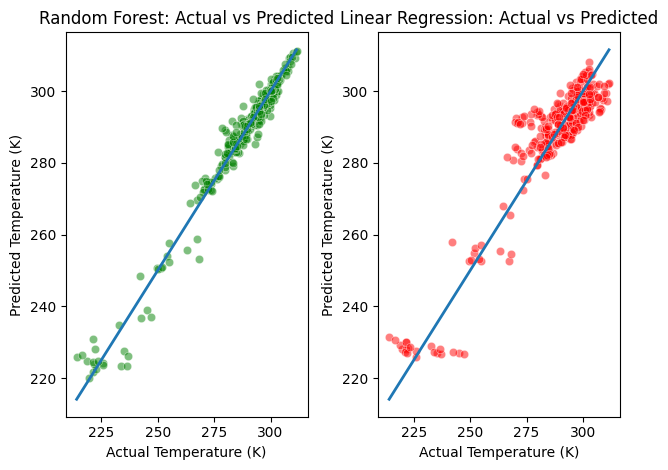

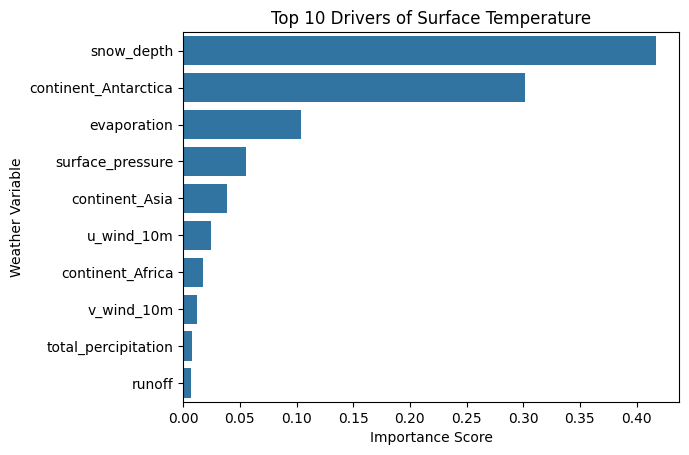

In [87]:
lr_predictions = models["Linear Regression"].predict(X_test_final)
rf_predictions = models["Random Forest Regression"].predict(X_test_final)

# Random Forest Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=rf_predictions, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], lw=2)
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual Temperature (K)')
plt.ylabel('Predicted Temperature (K)')

# Linear Regression Plot
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=lr_predictions, alpha=0.5, color='red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], lw=2)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Temperature (K)')
plt.ylabel('Predicted Temperature (K)')

plt.tight_layout()
plt.show()

rf_model = models["Random Forest Regression"]
importances = rf_model.feature_importances_
feature_names = X_train_final.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Top 10 Drivers of Surface Temperature')
plt.xlabel('Importance Score')
plt.ylabel('Weather Variable')
plt.show()


## **Section 6 - Insights & Conclusions**